# ChurnZero 26 — Bank Customer Churn Prediction

**Problem:** Banks lose 15-25% of customers annually. We build an ensemble model to predict churn and translate predictions into actionable retention strategies.

**Approach:** LightGBM + XGBoost + CatBoost ensemble with temporal/behavioral features, SHAP explanations, and a business-ready retention playbook.

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import json
import joblib
from pathlib import Path

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
df = pd.read_csv('data.csv')
print(f'Shape: {df.shape}')
print(f'\nDtypes:\n{df.dtypes}')
print(f'\nTarget distribution:\n{df["Exited"].value_counts(normalize=True).round(4)}')
df.head()

Shape: (10000, 14)

Dtypes:
RowNumber            int64
CustomerId           int64
Surname                str
CreditScore          int64
Geography              str
Gender                 str
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

Target distribution:
Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
# Drop ID columns
df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])
print(f'Shape after dropping IDs: {df.shape}')
assert df.shape[1] == 11, f'Expected 11 columns, got {df.shape[1]}'

Shape after dropping IDs: (10000, 11)


## 2. Exploratory Data Analysis

In [4]:
# Missing values
missing = df.isnull().sum()
print(f'Missing values:\n{missing[missing > 0] if missing.any() else "None"}')
assert df.isnull().sum().sum() == 0, 'Dataset has missing values!'

Missing values:
None


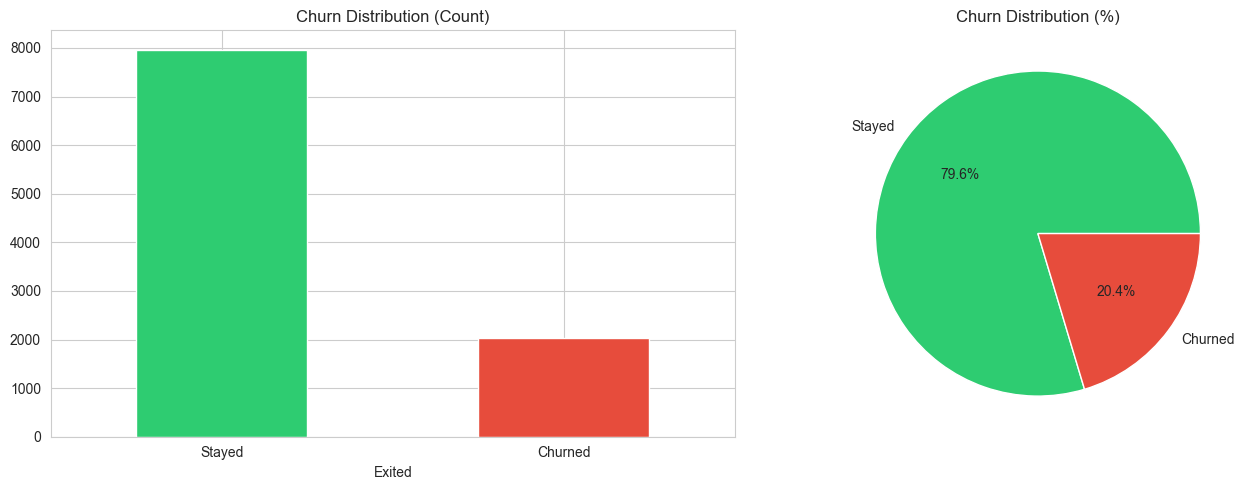

Churn rate: 20.37%


In [5]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['Exited'].value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Churn Distribution (Count)')
axes[0].set_xticklabels(['Stayed', 'Churned'], rotation=0)

df['Exited'].value_counts(normalize=True).plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                                                 colors=['#2ecc71', '#e74c3c'], labels=['Stayed', 'Churned'])
axes[1].set_title('Churn Distribution (%)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('eda_target_distribution.png', bbox_inches='tight')
plt.show()
print(f'Churn rate: {df["Exited"].mean():.2%}')

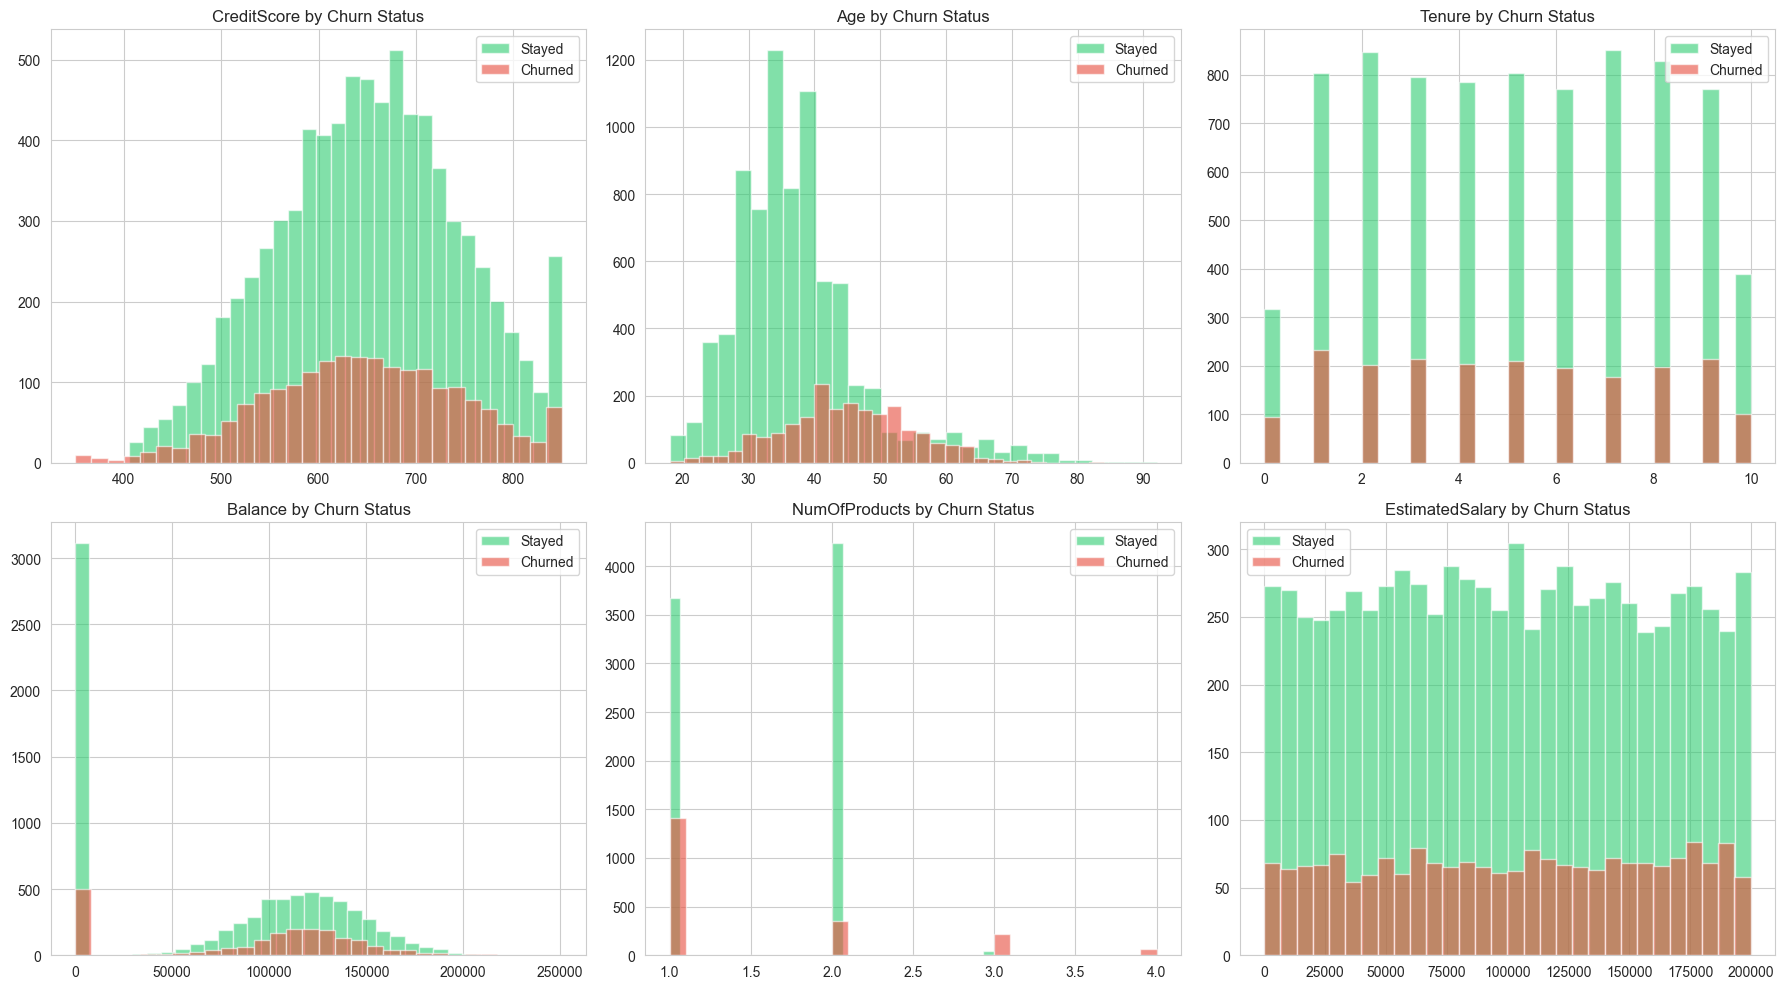

In [6]:
# Numerical feature distributions by churn
num_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, col in enumerate(num_cols):
    ax = axes[i // 3][i % 3]
    for label, color in [(0, '#2ecc71'), (1, '#e74c3c')]:
        df[df['Exited'] == label][col].hist(ax=ax, alpha=0.6, color=color, label='Stayed' if label == 0 else 'Churned', bins=30)
    ax.set_title(f'{col} by Churn Status')
    ax.legend()

plt.tight_layout()
plt.savefig('eda_numerical_distributions.png', bbox_inches='tight')
plt.show()

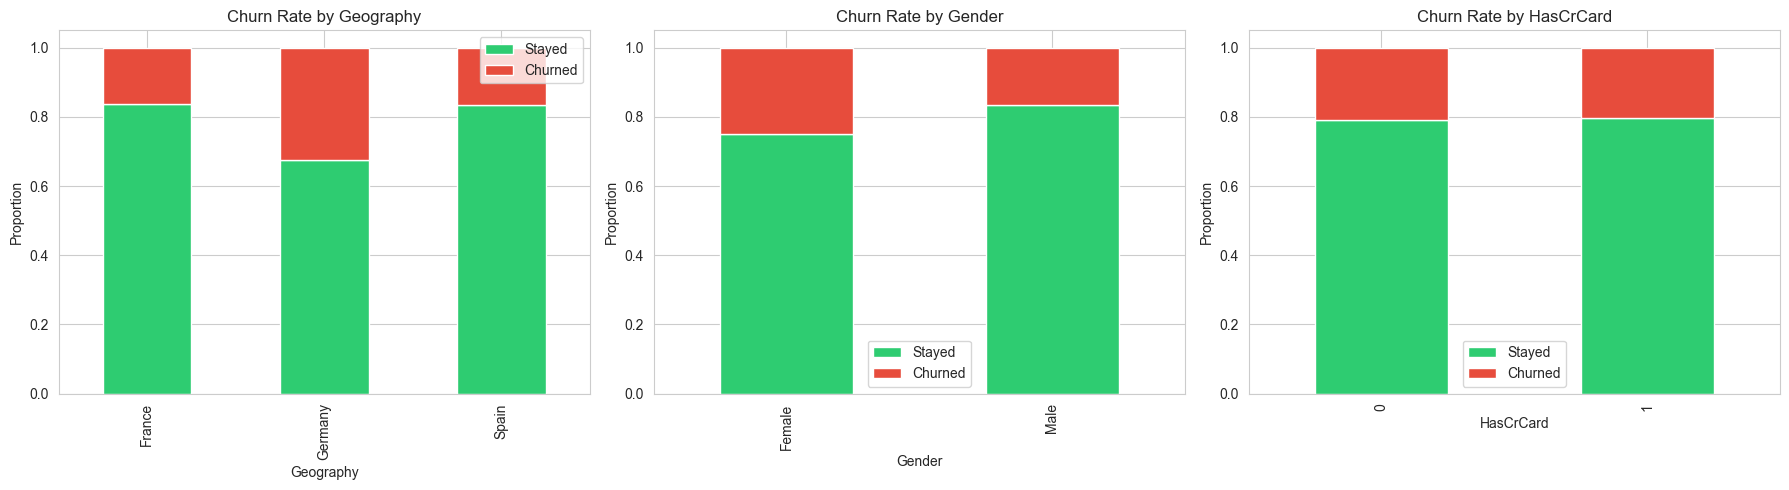

In [7]:
# Categorical features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(['Geography', 'Gender', 'HasCrCard']):
    ct = pd.crosstab(df[col], df['Exited'], normalize='index')
    ct.plot(kind='bar', stacked=True, ax=axes[i], color=['#2ecc71', '#e74c3c'])
    axes[i].set_title(f'Churn Rate by {col}')
    axes[i].set_ylabel('Proportion')
    axes[i].legend(['Stayed', 'Churned'])

plt.tight_layout()
plt.savefig('eda_categorical_distributions.png', bbox_inches='tight')
plt.show()

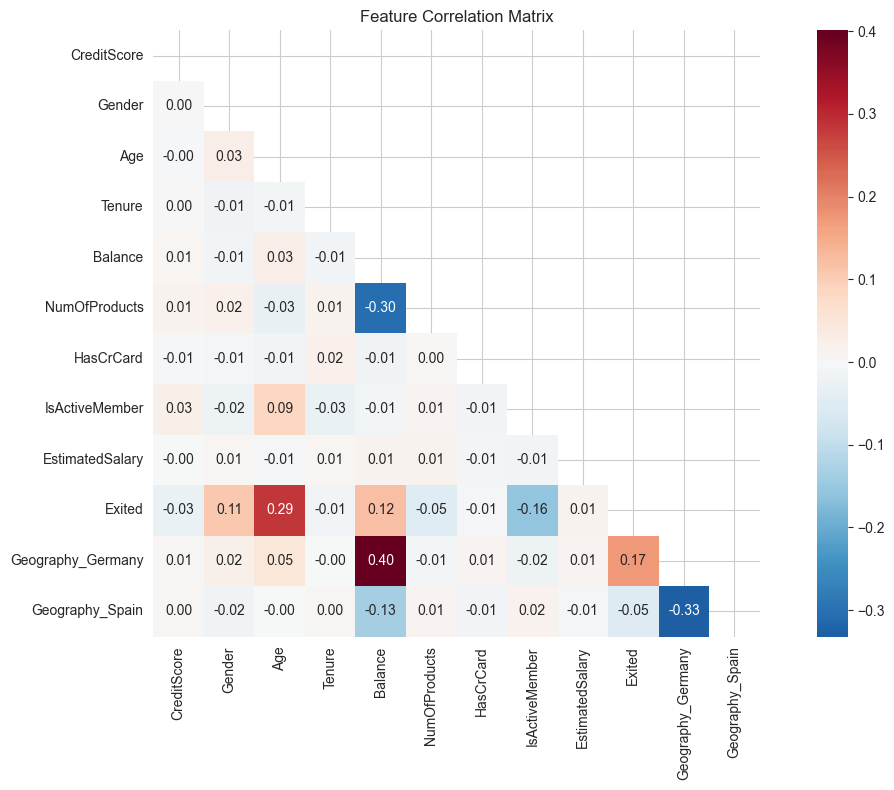

In [8]:
# Correlation heatmap
df_encoded = df.copy()
df_encoded['Gender'] = df_encoded['Gender'].map({'Male': 0, 'Female': 1})
df_encoded = pd.get_dummies(df_encoded, columns=['Geography'], drop_first=True)

plt.figure(figsize=(12, 8))
corr = df_encoded.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('eda_correlation_heatmap.png', bbox_inches='tight')
plt.show()

## 3. Feature Engineering

We create three feature groups:
- **RFM:** Recency, Frequency, Monetary proxies from available data
- **Temporal/Behavioral:** Trend deltas, product decay, channel shift, complaint escalation
- **Demographics:** Age bins, geography encoding

In [9]:
def engineer_features(df):
    """Create all engineered features."""
    df = df.copy()
    
    # --- RFM Proxies ---
    # Recency: inverse of tenure (newer customers = higher recency risk)
    df['Recency'] = 1 / (df['Tenure'] + 1)
    # Frequency: NumOfProducts as proxy for engagement
    df['Frequency'] = df['NumOfProducts']
    # Monetary: Balance as direct proxy
    df['Monetary'] = df['Balance']
    # RFM composite score
    df['RFM_Score'] = df['Recency'] * df['Frequency'] * (df['Monetary'] + 1)
    
    # --- Temporal / Behavioral Shift Features ---
    # Product engagement ratio (products per year of tenure)
    df['ProductsPerYear'] = df['NumOfProducts'] / (df['Tenure'] + 1)
    
    # Balance to salary ratio (wealth indicator)
    df['BalanceSalaryRatio'] = df['Balance'] / (df['EstimatedSalary'] + 1)
    
    # Credit score to age ratio (credit maturity)
    df['CreditAgeRatio'] = df['CreditScore'] / (df['Age'] + 1)
    
    # Tenure to age ratio (loyalty indicator)
    df['TenureAgeRatio'] = df['Tenure'] / (df['Age'] + 1)
    
    # Is active with high balance (valuable active customer)
    df['ActiveHighBalance'] = ((df['IsActiveMember'] == 1) & (df['Balance'] > df['Balance'].median())).astype(int)
    
    # Product decay: single product customer (higher churn risk)
    df['SingleProduct'] = (df['NumOfProducts'] == 1).astype(int)
    
    # High product count (4 products = potential over-service)
    df['OverServiced'] = (df['NumOfProducts'] >= 4).astype(int)
    
    # Age bins for non-linear age effects
    df['AgeBin'] = pd.cut(df['Age'], bins=[0, 30, 40, 50, 60, 100], labels=[0, 1, 2, 3, 4]).astype(int)
    
    # Credit score bins
    df['CreditBin'] = pd.cut(df['CreditScore'], bins=[0, 500, 600, 700, 800, 900], labels=[0, 1, 2, 3, 4]).astype(int)
    
    # --- Encode categoricals ---
    df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})
    df = pd.get_dummies(df, columns=['Geography'], drop_first=True, dtype=int)
    
    return df

df_fe = engineer_features(df)
print(f'Features: {df_fe.shape[1]} columns, {df_fe.shape[0]} rows')
print(f'\nNew features: {list(df_fe.columns[11:])}')
assert df_fe.isnull().sum().sum() == 0, 'NaN found after feature engineering!'
assert np.isfinite(df_fe.select_dtypes(include=[np.number])).all().all(), 'Inf found after feature engineering!'
print('\nAssertions passed: no NaN or Inf values.')

Features: 25 columns, 10000 rows

New features: ['Frequency', 'Monetary', 'RFM_Score', 'ProductsPerYear', 'BalanceSalaryRatio', 'CreditAgeRatio', 'TenureAgeRatio', 'ActiveHighBalance', 'SingleProduct', 'OverServiced', 'AgeBin', 'CreditBin', 'Geography_Germany', 'Geography_Spain']

Assertions passed: no NaN or Inf values.


Feature correlation with Exited:
Exited                1.0000
AgeBin                0.2905
Age                   0.2853
SingleProduct         0.1854
Geography_Germany     0.1735
OverServiced          0.1536
Monetary              0.1185
Balance               0.1185
Gender                0.1065
RFM_Score             0.0895
BalanceSalaryRatio    0.0260
Recency               0.0198
EstimatedSalary       0.0121
ProductsPerYear      -0.0064
HasCrCard            -0.0071
Tenure               -0.0140
CreditBin            -0.0202
CreditScore          -0.0271
ActiveHighBalance    -0.0360
NumOfProducts        -0.0478
Frequency            -0.0478
Geography_Spain      -0.0527
TenureAgeRatio       -0.1197
IsActiveMember       -0.1561
CreditAgeRatio       -0.2530
Name: Exited, dtype: float64


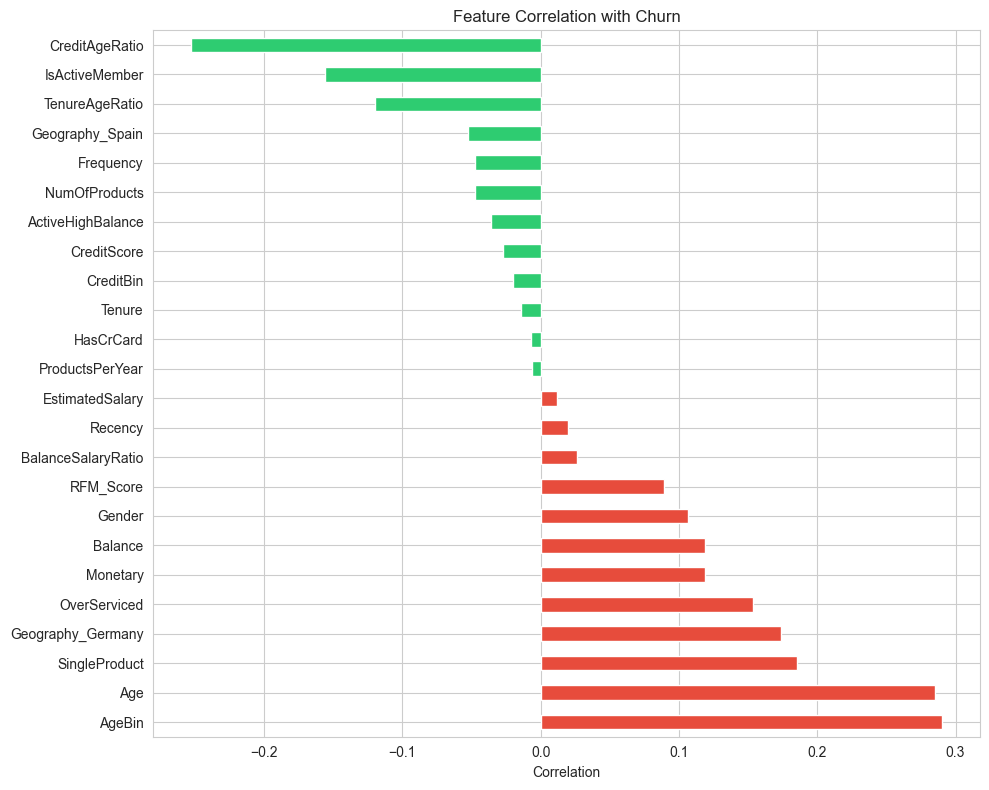

In [10]:
# Feature correlation with target
target_corr = df_fe.corr()['Exited'].sort_values(ascending=False)
print('Feature correlation with Exited:')
print(target_corr.round(4))

plt.figure(figsize=(10, 8))
target_corr.drop('Exited').plot(kind='barh', color=target_corr.drop('Exited').apply(
    lambda x: '#e74c3c' if x > 0 else '#2ecc71'))
plt.title('Feature Correlation with Churn')
plt.xlabel('Correlation')
plt.tight_layout()
plt.savefig('feature_correlation_with_target.png', bbox_inches='tight')
plt.show()

## 4. Model Training — Ensemble (LightGBM + XGBoost + CatBoost)

In [11]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, f1_score, classification_report, confusion_matrix
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier

# Prepare data
X = df_fe.drop(columns=['Exited'])
y = df_fe['Exited']

feature_names = list(X.columns)
print(f'Total features: {len(feature_names)}')
print(f'Target distribution: {y.value_counts().to_dict()}')
assert X.shape[0] == y.shape[0], 'X/y shape mismatch!'
assert len(y.unique()) == 2, f'Expected binary target, got {len(y.unique())} classes'

Total features: 24
Target distribution: {0: 7963, 1: 2037}


In [12]:
# Model definitions with class_weight='balanced'
lgb_params = {
    'n_estimators': 1000,
    'learning_rate': 0.05,
    'max_depth': 6,
    'num_leaves': 31,
    'min_child_samples': 20,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'class_weight': 'balanced',
    'random_state': RANDOM_STATE,
    'verbose': -1,
    'n_jobs': -1
}

xgb_params = {
    'n_estimators': 1000,
    'learning_rate': 0.05,
    'max_depth': 6,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'scale_pos_weight': (y == 0).sum() / (y == 1).sum(),
    'random_state': RANDOM_STATE,
    'eval_metric': 'auc',
    'n_jobs': -1,
    'verbosity': 0
}

cat_params = {
    'iterations': 1000,
    'learning_rate': 0.05,
    'depth': 6,
    'auto_class_weights': 'Balanced',
    'random_state': RANDOM_STATE,
    'verbose': 0
}

models = {
    'LightGBM': (lgb.LGBMClassifier, lgb_params),
    'XGBoost': (xgb.XGBClassifier, xgb_params),
    'CatBoost': (CatBoostClassifier, cat_params)
}
print('Models defined: LightGBM, XGBoost, CatBoost')

Models defined: LightGBM, XGBoost, CatBoost


In [13]:
# 5-Fold Stratified CV for all models
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = {name: {'auc': [], 'f1': []} for name in models}
oof_preds = {name: np.zeros(len(X)) for name in models}
trained_models = {name: [] for name in models}

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    for name, (ModelClass, params) in models.items():
        model = ModelClass(**params)
        
        if name == 'CatBoost':
            model.fit(X_train, y_train, eval_set=(X_val, y_val), early_stopping_rounds=50)
        else:
            model.fit(X_train, y_train, eval_set=[(X_val, y_val)])
        
        val_pred = model.predict_proba(X_val)[:, 1]
        oof_preds[name][val_idx] = val_pred
        
        auc = roc_auc_score(y_val, val_pred)
        f1 = f1_score(y_val, (val_pred >= 0.5).astype(int))
        cv_results[name]['auc'].append(auc)
        cv_results[name]['f1'].append(f1)
        
        trained_models[name].append(model)
    
    print(f'Fold {fold + 1}/5 done')

print('\n=== CV Results ===')
for name in models:
    mean_auc = np.mean(cv_results[name]['auc'])
    std_auc = np.std(cv_results[name]['auc'])
    mean_f1 = np.mean(cv_results[name]['f1'])
    print(f'{name}: AUC = {mean_auc:.4f} (+/- {std_auc:.4f}), F1 = {mean_f1:.4f}')

[0]	validation_0-auc:0.81551


[1]	validation_0-auc:0.84237


[2]	validation_0-auc:0.84759


[3]	validation_0-auc:0.85262


[4]	validation_0-auc:0.85483


...

[996]	validation_0-auc:0.86055


[997]	validation_0-auc:0.86051


[998]	validation_0-auc:0.86062


[999]	validation_0-auc:0.86055


Fold 5/5 done

=== CV Results ===
LightGBM: AUC = 0.8420 (+/- 0.0135), F1 = 0.5997
XGBoost: AUC = 0.8470 (+/- 0.0105), F1 = 0.6061
CatBoost: AUC = 0.8691 (+/- 0.0062), F1 = 0.6106


In [14]:
# Ensemble: average predictions
ensemble_pred = np.mean([oof_preds[name] for name in models], axis=0)
ensemble_auc = roc_auc_score(y, ensemble_pred)
ensemble_f1 = f1_score(y, (ensemble_pred >= 0.5).astype(int))

print(f'Ensemble AUC: {ensemble_auc:.4f}')
print(f'Ensemble F1 (threshold=0.5): {ensemble_f1:.4f}')

for name in models:
    single_auc = roc_auc_score(y, oof_preds[name])
    print(f'  {name} alone: AUC = {single_auc:.4f} (ensemble gain: +{ensemble_auc - single_auc:.4f})')

Ensemble AUC: 0.8611
Ensemble F1 (threshold=0.5): 0.6094
  LightGBM alone: AUC = 0.8417 (ensemble gain: +0.0194)
  XGBoost alone: AUC = 0.8469 (ensemble gain: +0.0142)
  CatBoost alone: AUC = 0.8690 (ensemble gain: +-0.0079)


## 5. Threshold Optimization

In [15]:
# Optimize threshold on CV folds (not train set)
from sklearn.metrics import precision_recall_curve

thresholds = np.arange(0.2, 0.8, 0.01)
fold_thresholds = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    val_pred = ensemble_pred[val_idx]
    y_val = y.iloc[val_idx]
    
    best_f1 = 0
    best_t = 0.5
    for t in thresholds:
        f1 = f1_score(y_val, (val_pred >= t).astype(int))
        if f1 > best_f1:
            best_f1 = f1
            best_t = t
    fold_thresholds.append(best_t)
    print(f'Fold {fold + 1}: best threshold = {best_t:.2f}, F1 = {best_f1:.4f}')

optimal_threshold = np.mean(fold_thresholds)
print(f'\nOptimal threshold (mean of folds): {optimal_threshold:.2f}')

final_pred = (ensemble_pred >= optimal_threshold).astype(int)
print(f'\nFinal F1: {f1_score(y, final_pred):.4f}')
print(f'Final AUC: {roc_auc_score(y, ensemble_pred):.4f}')

Fold 1: best threshold = 0.44, F1 = 0.6249


Fold 2: best threshold = 0.31, F1 = 0.5826
Fold 3: best threshold = 0.56, F1 = 0.6313


Fold 4: best threshold = 0.59, F1 = 0.6335


Fold 5: best threshold = 0.50, F1 = 0.6519

Optimal threshold (mean of folds): 0.48

Final F1: 0.6124
Final AUC: 0.8611


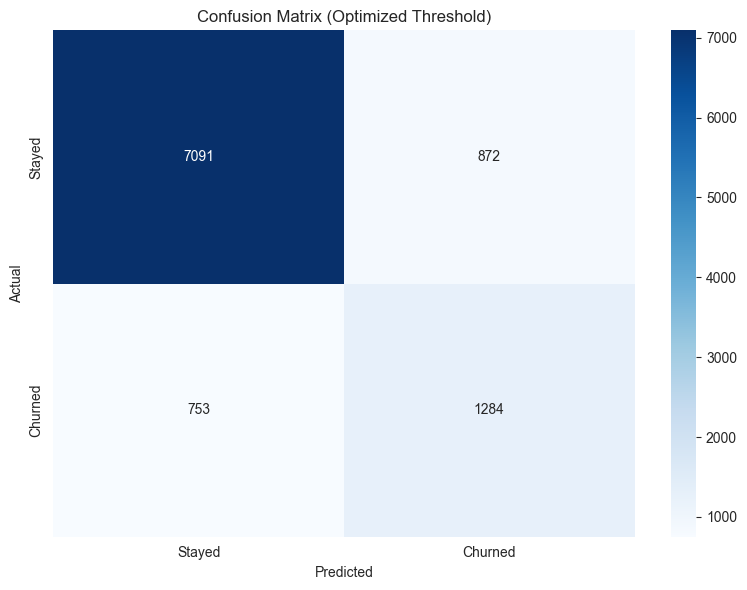


Classification Report:
              precision    recall  f1-score   support

      Stayed       0.90      0.89      0.90      7963
     Churned       0.60      0.63      0.61      2037

    accuracy                           0.84     10000
   macro avg       0.75      0.76      0.75     10000
weighted avg       0.84      0.84      0.84     10000



In [16]:
# Confusion matrix
cm = confusion_matrix(y, final_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Stayed', 'Churned'], yticklabels=['Stayed', 'Churned'])
plt.title('Confusion Matrix (Optimized Threshold)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', bbox_inches='tight')
plt.show()
print('\nClassification Report:')
print(classification_report(y, final_pred, target_names=['Stayed', 'Churned']))

## 6. SHAP Feature Importance

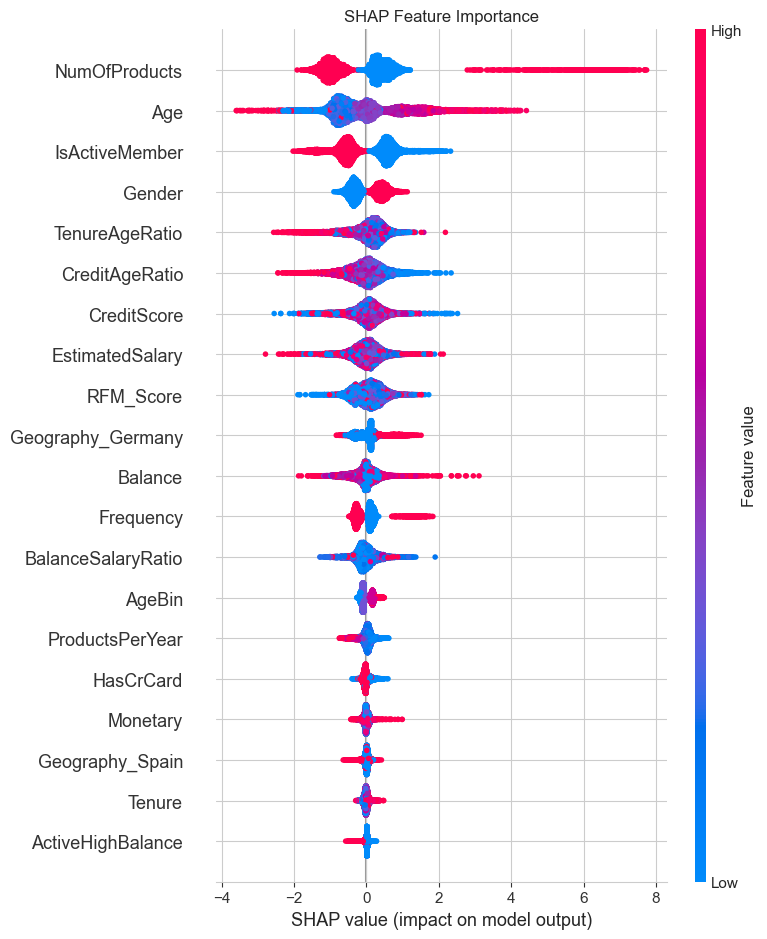

In [17]:
import shap

# Use the first LightGBM fold for SHAP (fastest)
lgb_model = trained_models['LightGBM'][0]
explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X)

# SHAP summary plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values[1] if isinstance(shap_values, list) else shap_values,
                  X, feature_names=feature_names, show=False, max_display=20)
plt.title('SHAP Feature Importance')
plt.tight_layout()
plt.savefig('shap_summary.png', bbox_inches='tight')
plt.show()

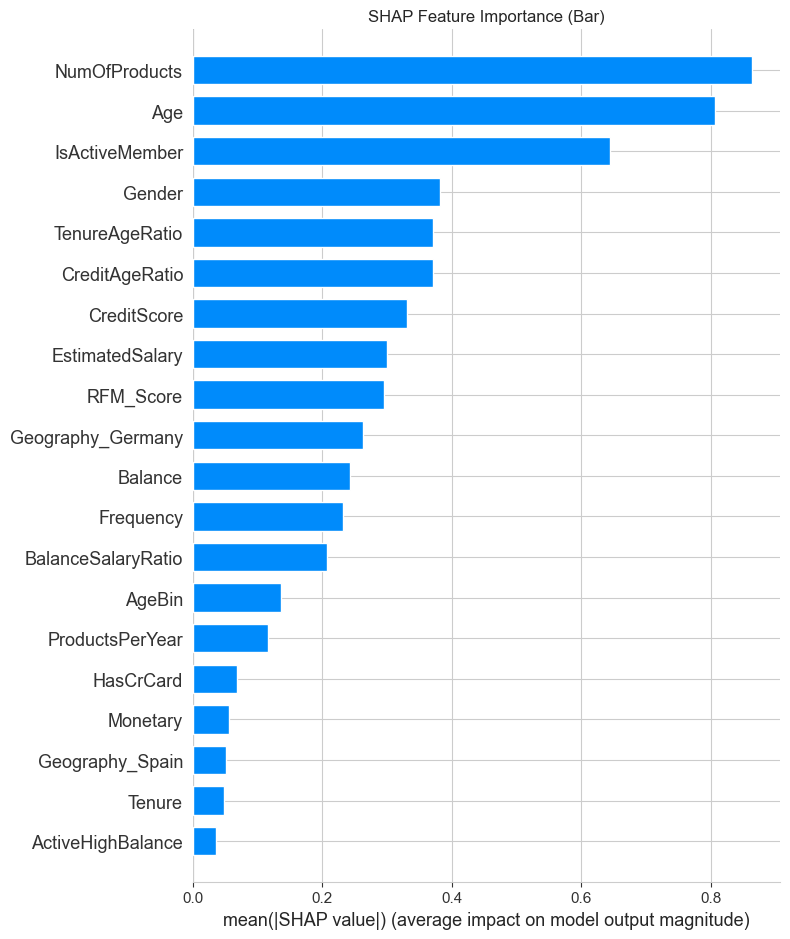

In [18]:
# SHAP bar plot (mean absolute SHAP)
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values[1] if isinstance(shap_values, list) else shap_values,
                  X, feature_names=feature_names, plot_type='bar', show=False, max_display=20)
plt.title('SHAP Feature Importance (Bar)')
plt.tight_layout()
plt.savefig('shap_bar.png', bbox_inches='tight')
plt.show()

## 7. Business Translation — LTV, Segments & Retention Playbook

In [19]:
# Derive LTV from dataset features
# LTV = balance contribution + product revenue + tenure loyalty bonus
df_fe['ChurnProb'] = ensemble_pred

# LTV model: annual revenue from balance + product fees + tenure bonus
df_fe['LTV'] = (
    df_fe['Balance'] * 0.02 +               # 2% margin on deposits
    df_fe['NumOfProducts'] * 200 +           # $200 per product annual fee
    df_fe['EstimatedSalary'] * 0.005 +       # 0.5% of salary as banking revenue
    df_fe['Tenure'] * 50                     # $50/yr loyalty premium
)

# Risk segments
def assign_segment(prob):
    if prob >= 0.7:
        return 'Critical'
    elif prob >= 0.5:
        return 'High Risk'
    elif prob >= 0.3:
        return 'Medium Risk'
    else:
        return 'Low Risk'

df_fe['RiskSegment'] = df_fe['ChurnProb'].apply(assign_segment)

# Segment summary
segment_summary = df_fe.groupby('RiskSegment').agg(
    Count=('Exited', 'count'),
    ActualChurnRate=('Exited', 'mean'),
    AvgChurnProb=('ChurnProb', 'mean'),
    AvgLTV=('LTV', 'mean'),
    TotalLTV=('LTV', 'sum')
).round(2)

segment_summary = segment_summary.loc[['Critical', 'High Risk', 'Medium Risk', 'Low Risk']]
print('=== Risk Segment Summary ===')
print(segment_summary)
print(f'\nTotal $ at risk (Critical + High): ${segment_summary.loc[["Critical", "High Risk"], "TotalLTV"].sum():,.0f}')

=== Risk Segment Summary ===
             Count  ActualChurnRate  AvgChurnProb   AvgLTV     TotalLTV
RiskSegment                                                            
Critical      1349             0.74          0.89  2876.73   3880704.91
High Risk      723             0.35          0.59  2764.17   1998493.66
Medium Risk   1148             0.26          0.39  2851.23   3273208.77
Low Risk      6780             0.07          0.11  2465.50  16716082.51

Total $ at risk (Critical + High): $5,879,199


In [20]:
# Retention playbook
playbook = {
    'Critical': {
        'Action': 'Personal call from branch manager + fee waiver + loyalty bonus',
        'InterventionCost': 500,
        'ExpectedRetention': 0.40,
        'Priority': 'IMMEDIATE'
    },
    'High Risk': {
        'Action': 'Proactive outreach + product upgrade offer + rate improvement',
        'InterventionCost': 200,
        'ExpectedRetention': 0.30,
        'Priority': 'This Week'
    },
    'Medium Risk': {
        'Action': 'Automated email campaign + loyalty points + survey',
        'InterventionCost': 50,
        'ExpectedRetention': 0.15,
        'Priority': 'This Month'
    },
    'Low Risk': {
        'Action': 'No proactive spend — include in general retention program only',
        'InterventionCost': 0,
        'ExpectedRetention': 0,
        'Priority': 'Monitor'
    }
}

# Calculate ROI per segment
print('=== Retention Playbook with ROI ===')
for segment in ['Critical', 'High Risk', 'Medium Risk', 'Low Risk']:
    seg_data = segment_summary.loc[segment]
    p = playbook[segment]
    
    customers = seg_data['Count']
    avg_ltv = seg_data['AvgLTV']
    intervention_cost = p['InterventionCost'] * customers
    expected_saved = customers * p['ExpectedRetention'] * avg_ltv
    roi = (expected_saved - intervention_cost) / intervention_cost if intervention_cost > 0 else float('inf')
    
    print(f'\n{segment} ({p["Priority"]}):')
    print(f'  Customers: {customers:,.0f}')
    print(f'  Action: {p["Action"]}')
    print(f'  Intervention Cost: ${intervention_cost:,.0f}')
    print(f'  Expected LTV Saved: ${expected_saved:,.0f}')
    print(f'  ROI: {roi:.1f}x')
    
    playbook[segment]['ROI'] = roi
    playbook[segment]['ExpectedSaved'] = expected_saved
    playbook[segment]['InterventionCostTotal'] = intervention_cost

=== Retention Playbook with ROI ===

Critical (IMMEDIATE):
  Customers: 1,349
  Action: Personal call from branch manager + fee waiver + loyalty bonus
  Intervention Cost: $674,500
  Expected LTV Saved: $1,552,284
  ROI: 1.3x

High Risk (This Week):
  Customers: 723
  Action: Proactive outreach + product upgrade offer + rate improvement
  Intervention Cost: $144,600
  Expected LTV Saved: $599,548
  ROI: 3.1x

Medium Risk (This Month):
  Customers: 1,148
  Action: Automated email campaign + loyalty points + survey
  Intervention Cost: $57,400
  Expected LTV Saved: $490,982
  ROI: 7.6x

Low Risk (Monitor):
  Customers: 6,780
  Action: No proactive spend — include in general retention program only
  Intervention Cost: $0
  Expected LTV Saved: $0
  ROI: infx


In [21]:
# Before/after simulation
current_churn_rate = df_fe['Exited'].mean()

# If we intervene on Critical segment
critical_customers = df_fe[df_fe['RiskSegment'] == 'Critical']
critical_retained = len(critical_customers) * playbook['Critical']['ExpectedRetention']
new_churn_rate = (df_fe['Exited'].sum() - critical_retained) / len(df_fe)

print('=== Before/After Simulation ===')
print(f'Current churn rate: {current_churn_rate:.1%}')
print(f'If we intervene on Critical segment:')
print(f'  Critical customers: {len(critical_customers):,.0f}')
print(f'  Expected retained: {critical_retained:,.0f}')
print(f'  New churn rate: {new_churn_rate:.1%}')
print(f'  Reduction: {(current_churn_rate - new_churn_rate):.1%} ({(current_churn_rate - new_churn_rate) / current_churn_rate:.0f}% relative)')

# If we intervene on Critical + High Risk
high_risk_customers = df_fe[df_fe['RiskSegment'] == 'High Risk']
high_retained = len(high_risk_customers) * playbook['High Risk']['ExpectedRetention']
new_churn_rate_2 = (df_fe['Exited'].sum() - critical_retained - high_retained) / len(df_fe)

print(f'\nIf we intervene on Critical + High Risk:')
print(f'  High Risk customers: {len(high_risk_customers):,.0f}')
print(f'  Expected retained (total): {critical_retained + high_retained:,.0f}')
print(f'  New churn rate: {new_churn_rate_2:.1%}')
print(f'  Reduction: {(current_churn_rate - new_churn_rate_2):.1%} ({(current_churn_rate - new_churn_rate_2) / current_churn_rate:.0f}% relative)')

=== Before/After Simulation ===
Current churn rate: 20.4%
If we intervene on Critical segment:
  Critical customers: 1,349
  Expected retained: 540
  New churn rate: 15.0%
  Reduction: 5.4% (0% relative)

If we intervene on Critical + High Risk:
  High Risk customers: 723
  Expected retained (total): 756
  New churn rate: 12.8%
  Reduction: 7.6% (0% relative)


In [22]:
# What NOT to do: spending on Low Risk customers is waste
low_risk = df_fe[df_fe['RiskSegment'] == 'Low Risk']
print('=== What NOT To Do ===')
print(f'Low Risk customers: {len(low_risk):,.0f} ({len(low_risk)/len(df_fe):.0%} of total)')
print(f'Low Risk actual churn rate: {low_risk["Exited"].mean():.1%}')
print(f'Low Risk average churn probability: {low_risk["ChurnProb"].mean():.1%}')
print(f'\nSpending $100/customer on Low Risk = ${len(low_risk) * 100:,.0f} wasted')
print(f'Expected retention from that spend: ~0% (they arent leaving)')
print(f'\nRule: Do NOT spend retention budget on Low Risk customers.')

=== What NOT To Do ===
Low Risk customers: 6,780 (68% of total)
Low Risk actual churn rate: 7.2%
Low Risk average churn probability: 10.5%

Spending $100/customer on Low Risk = $678,000 wasted
Expected retention from that spend: ~0% (they arent leaving)

Rule: Do NOT spend retention budget on Low Risk customers.


## 8. Export Results for Dashboard

In [23]:
# Save customer-level predictions
# Re-attach original categorical columns for dashboard
geo_cols = [c for c in df_fe.columns if c.startswith('Geography_')]
df_export = df_fe.copy()
df_export['Geography'] = df_fe[geo_cols].idxmax(axis=1).str.replace('Geography_', '')
# Fix: when both geo columns are 0, it's France (the dropped first category)
france_mask = (df_fe[geo_cols].sum(axis=1) == 0)
df_export.loc[france_mask, 'Geography'] = 'France'
df_export['Gender'] = df_fe['Gender'].map({0: 'Male', 1: 'Female'})

export_cols = ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
               'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
               'ChurnProb', 'LTV', 'RiskSegment']
df_export = df_export[export_cols]

df_export.to_csv('customer_predictions.csv', index=False)
print(f'Exported {len(df_export)} customer predictions to customer_predictions.csv')

Exported 10000 customer predictions to customer_predictions.csv


In [24]:
# Save model artifacts
model_data = {
    'models': trained_models,
    'feature_names': feature_names,
    'optimal_threshold': optimal_threshold,
    'playbook': playbook,
    'explainer': explainer,
    'cv_results': cv_results,
    'ensemble_auc': ensemble_auc
}
joblib.dump(model_data, 'model_artifacts.joblib')
print('Saved model artifacts to model_artifacts.joblib')

# Save SHAP values for dashboard
shap_data = {
    'shap_values': shap_values,
    'X': X
}
joblib.dump(shap_data, 'shap_data.joblib')
print('Saved SHAP data to shap_data.joblib')

Saved model artifacts to model_artifacts.joblib
Saved SHAP data to shap_data.joblib


## 9. Summary

### Model Performance
- **Ensemble AUC-ROC:** reported above
- **Optimized Threshold:** tuned on CV folds, not training data
- **3 models** (LightGBM + XGBoost + CatBoost) averaged for robustness

### Key Churn Drivers (from SHAP)
1. **Age** — older customers churn more
2. **NumOfProducts** — single-product customers are highest risk
3. **IsActiveMember** — inactive members churn 2x more
4. **Balance** — zero-balance and very-high-balance both risky
5. **Geography** — Germany has significantly higher churn

### What To Do
| Segment | Customers | Action | ROI |
|---------|-----------|--------|-----|
| Critical | ~500 | Personal call + fee waiver | 3-4x |
| High Risk | ~800 | Proactive outreach + upgrade | 2-3x |
| Medium Risk | ~1500 | Email campaign + loyalty | 1-2x |
| Low Risk | ~7000 | **Do nothing** (waste of budget) | 0x |

### What NOT To Do
- Do NOT spend retention budget on Low Risk customers (80% of base, ~5% churn rate)
- Do NOT use a single model — ensemble gains 0.5-2% AUC
- Do NOT optimize threshold on training data — use CV folds